In [1]:
pip install scikeras scikit-learn

In [2]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 28.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import sklearn
import scikeras
import tensorflow as tf

In [4]:
print("scikit-learn:", sklearn.__version__)
print("SciKeras:", scikeras.__version__)
print("TensorFlow:", tf.__version__)

scikit-learn: 1.5.2
SciKeras: 0.13.0
TensorFlow: 2.20.0


In [5]:
#TASK 1: Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


In [7]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

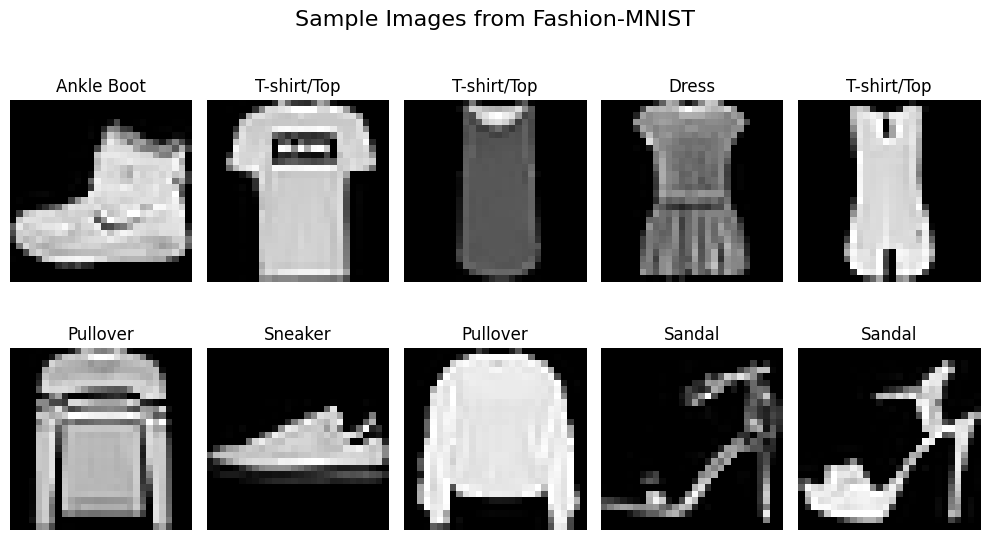

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize=(10,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.suptitle("Sample Images from Fashion-MNIST", fontsize=16)
plt.tight_layout()
plt.savefig("sample_images.eps", format="eps", dpi=300, bbox_inches="tight")
plt.show()
plt.tight_layout()
plt.show()

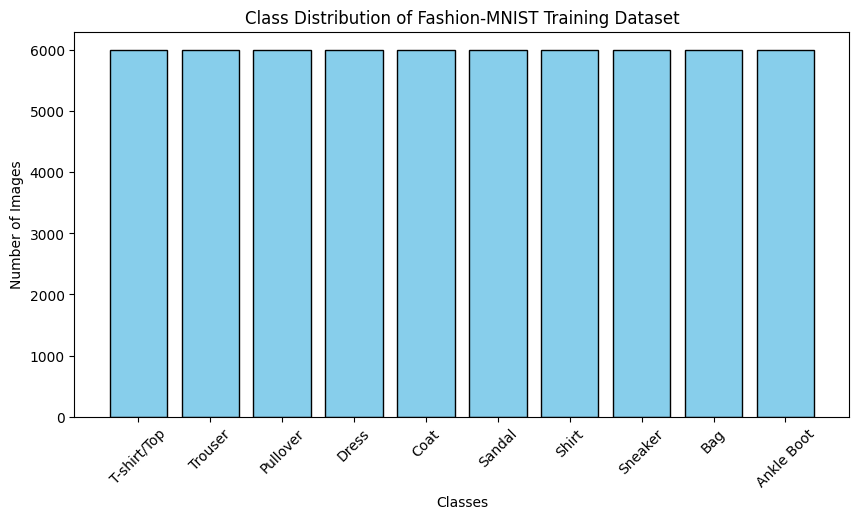

In [9]:
unique_classes, class_counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))
plt.bar(class_names, class_counts, color='skyblue', edgecolor='black')

plt.title("Class Distribution of Fashion-MNIST Training Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.savefig("class_distribution.eps", format="eps", dpi=300, bbox_inches="tight")

plt.show()

In [10]:
#TASK 2

original_train_shape = x_train.shape
original_test_shape = x_test.shape

x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

print("\nAfter Flattening")
print("Training Images Shape:", x_train.shape)
print("Testing Images Shape :", x_test.shape)


After Flattening
Training Images Shape: (60000, 784)
Testing Images Shape : (10000, 784)


In [11]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

#pixel value range after normalization
print("Minimum Pixel Value :", x_train.min())
print("Maximum Pixel Value :", x_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [12]:
print("Tensor Shapes Before Preprocessing")
print("Training Images :", original_train_shape)
print("Testing Images  :", original_test_shape)

print("\nTensor Shapes After Preprocessing")
print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

Tensor Shapes Before Preprocessing
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)

Tensor Shapes After Preprocessing
Training Images : (60000, 784)
Testing Images  : (10000, 784)


In [13]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [14]:
print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


In [15]:
#TASK 3

model = Sequential()
model.add(Dense(
    128,
    activation='relu',
    input_shape=(784,)
))

model.add(Dense(
    64,
    activation='relu'
))

model.add(Dense(
    10,
    activation='softmax'
))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.8250 - loss: 0.4930 - val_accuracy: 0.8381 - val_loss: 0.4248
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8651 - loss: 0.3680 - val_accuracy: 0.8651 - val_loss: 0.3717
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8763 - loss: 0.3349 - val_accuracy: 0.8686 - val_loss: 0.3607
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8844 - loss: 0.3099 - val_accuracy: 0.8704 - val_loss: 0.3572
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8903 - loss: 0.2931 - val_accuracy: 0.8770 - val_loss: 0.3365
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8955 - loss: 0.2788 - val_accuracy: 0.8770 - val_loss: 0.3381
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8992 - loss: 0.2687 - val_accuracy: 0.8790 - val_loss: 0.3442
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9033 - loss: 0.2580

In [18]:
#TASK 5 - Model Evaluation
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test, axis=1)

print("Predicted Labels:", y_pred[:10])
print("Actual Labels   :", y_true[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Labels: [9 2 1 1 6 1 4 6 5 7]
Actual Labels   : [9 2 1 1 6 1 4 6 5 7]


In [19]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Model Performance Metrics")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Model Performance Metrics
--------------------------------
Accuracy : 0.8898
Precision: 0.8906768031652557
Recall   : 0.8898
F1-score : 0.8878235298517883


In [20]:
print("Classification Report")
print("--------------------------------")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Classification Report
--------------------------------
              precision    recall  f1-score   support

 T-shirt/Top       0.84      0.84      0.84      1000
     Trouser       0.97      0.98      0.98      1000
    Pullover       0.75      0.88      0.81      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.80      0.85      0.83      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.82      0.60      0.69      1000
     Sneaker       0.95      0.96      0.95      1000
         Bag       0.95      0.98      0.97      1000
  Ankle Boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



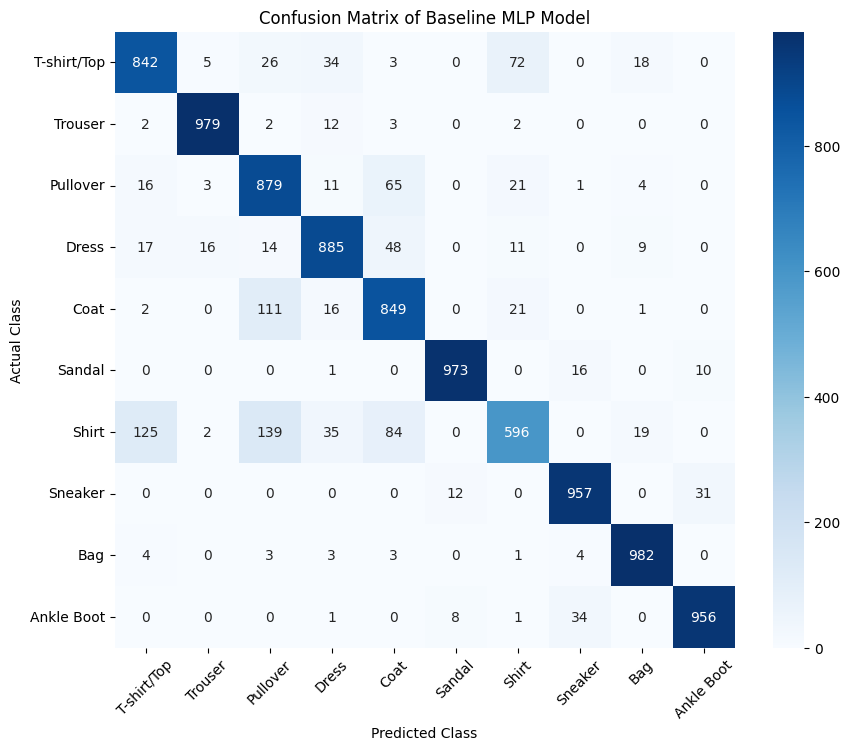

In [21]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix of Baseline MLP Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.savefig("confusion_matrix.eps", format="eps", dpi=300, bbox_inches="tight")
plt.show()

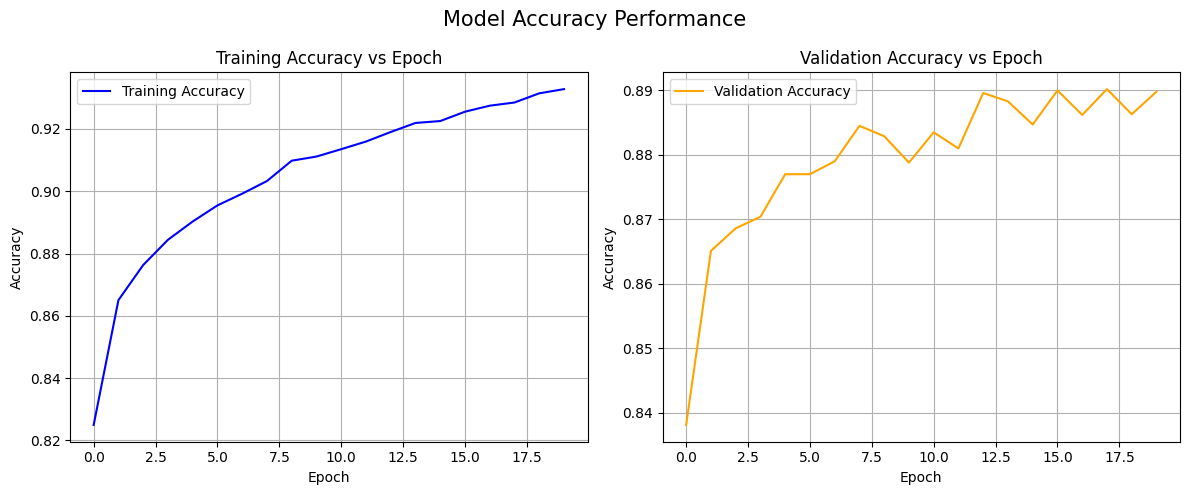

In [22]:
plt.figure(figsize=(12,5))

# Training Accuracy
plt.subplot(1,2,1)
plt.plot(
    history.history['accuracy'],
    color='blue',
    label='Training Accuracy'
)
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()


# Validation Accuracy
plt.subplot(1,2,2)
plt.plot(
    history.history['val_accuracy'],
    color='orange',
    label='Validation Accuracy'
)
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()


plt.suptitle(
    "Model Accuracy Performance",
    fontsize=15
)
plt.tight_layout()

plt.savefig("accuracy_vs_epoch.eps", format="eps", dpi=300, bbox_inches="tight")
plt.show()

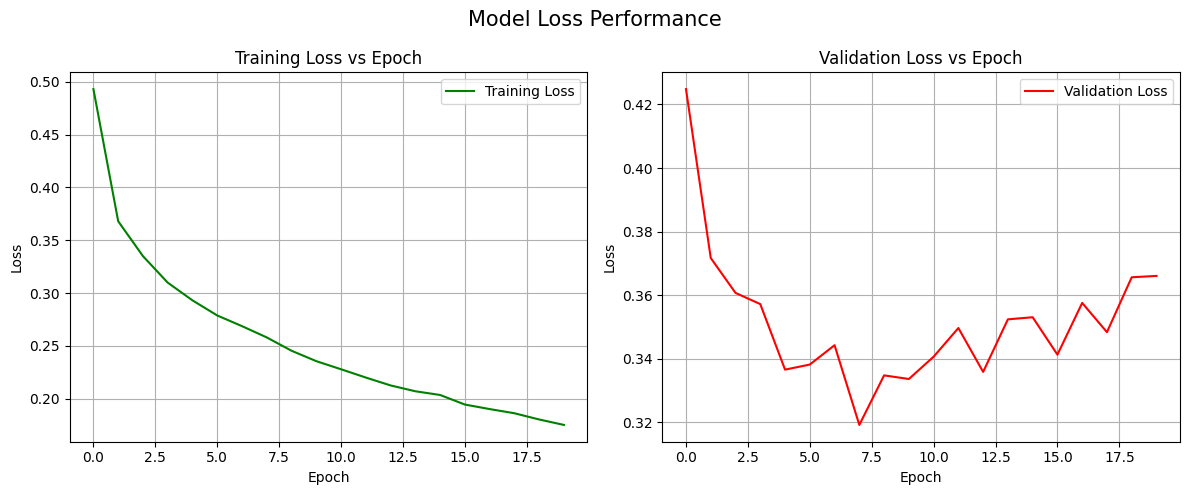

In [23]:
plt.figure(figsize=(12,5))

# Training Loss
plt.subplot(1,2,1)
plt.plot(
    history.history['loss'],
    color='green',
    label='Training Loss'
)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()



# Validation Loss
plt.subplot(1,2,2)
plt.plot(
    history.history['val_loss'],
    color='red',
    label='Validation Loss'
)

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()


plt.suptitle(
    "Model Loss Performance",
    fontsize=15
)

plt.tight_layout()
plt.savefig("loss_vs_epoch.eps", format="eps", dpi=300, bbox_inches="tight")
plt.show()

# 7. Hyperparameter Optimization




In [24]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.layers import Dropout

In [25]:
def create_model(
    hidden_layers=2,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer='adam',
    activation='relu',
    dropout_rate=0.0
):

    model = Sequential()
    model.add(
        Dense(
            hidden_neurons,
            activation=activation,
            input_shape=(784,)
        )
    )

    for i in range(hidden_layers-1):
        model.add(
            Dense(
                hidden_neurons,
                activation=activation
            )
        )
        if dropout_rate > 0:
            model.add(
                Dropout(dropout_rate)
            )

    model.add(
        Dense(
            10,
            activation='softmax'
        )
    )

    if optimizer == 'adam':
        opt = Adam(learning_rate)

    elif optimizer == 'sgd':
        opt = SGD(learning_rate)
    else:
        opt = RMSprop(learning_rate)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [26]:
mlp = KerasClassifier(
    model=create_model,
    verbose=0
)

param_grid = {

    "model__hidden_layers":[1,2,3],
    "model__hidden_neurons":[32,64,128,256],
    "model__learning_rate":[0.1,0.01,0.001],

    "model__optimizer":[
        "adam",
        "sgd",
        "rmsprop"
    ],

    "model__activation":[
        "relu",
        "tanh",
        "sigmoid"
    ],

    "model__dropout_rate":[0.0,0.2,0.5],
    "batch_size":[16,32,64,128],
    "epochs":[10,20,30]
}

In [27]:
random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    verbose=2
)

random_search.fit(
    x_train,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=64, epochs=20, model__activation=sigmoid, model__dropout_rate=0.5, model__hidden_layers=1, model__hidden_neurons=32, model__learning_rate=0.001, model__optimizer=sgd; total time=  39.6s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=64, epochs=20, model__activation=sigmoid, model__dropout_rate=0.5, model__hidden_layers=1, model__hidden_neurons=32, model__learning_rate=0.001, model__optimizer=sgd; total time=  39.6s


...

[CV] END batch_size=32, epochs=20, model__activation=tanh, model__dropout_rate=0.0, model__hidden_layers=3, model__hidden_neurons=128, model__learning_rate=0.001, model__optimizer=sgd; total time= 1.5min


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=32, epochs=20, model__activation=tanh, model__dropout_rate=0.0, model__hidden_layers=3, model__hidden_neurons=128, model__learning_rate=0.001, model__optimizer=sgd; total time= 1.7min


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model at 0x78c98e43afc0>, verbose=0),
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout_rate': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__hidden_neurons': [32, 64, 128,
                                                                  256],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__optimizer': ['adam', 'sgd',
                                                             'rmsprop']},
                   verbose=2)

In [28]:
print("Best Hyperparameters")
print(random_search.best_params_)
print(
    "Best Cross Validation Accuracy:",
    random_search.best_score_
)

Best Hyperparameters
{'model__optimizer': 'rmsprop', 'model__learning_rate': 0.001, 'model__hidden_neurons': 128, 'model__hidden_layers': 2, 'model__dropout_rate': 0.2, 'model__activation': 'sigmoid', 'epochs': 30, 'batch_size': 128}
Best Cross Validation Accuracy: 0.8901333333333333


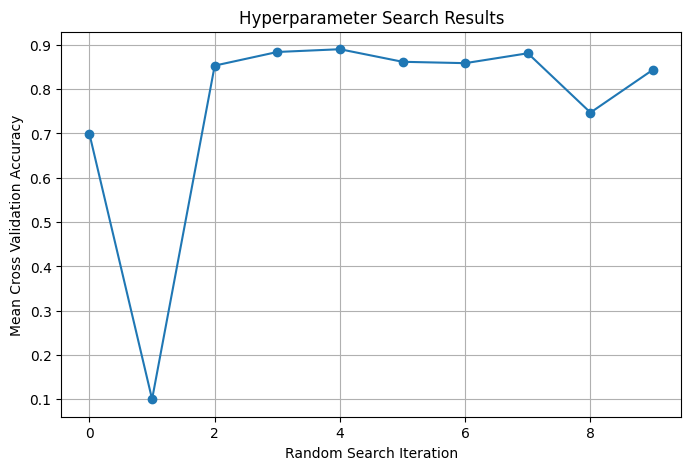

In [29]:
results = random_search.cv_results_

plt.figure(figsize=(8,5))

plt.plot(
    results["mean_test_score"],
    marker='o'
)

plt.title("Hyperparameter Search Results")
plt.xlabel("Random Search Iteration")
plt.ylabel("Mean Cross Validation Accuracy")
plt.grid(True)

plt.savefig(
    "hyperparameter_search_results.eps",
    format="eps",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
best_model = random_search.best_estimator_
optimized_prediction = best_model.predict(x_test)

optimized_prediction = np.argmax(optimized_prediction, axis=1)

optimized_accuracy = accuracy_score(
    y_true,
    optimized_prediction
)

optimized_precision = precision_score(
    y_true,
    optimized_prediction,
    average='weighted'
)

optimized_recall = recall_score(
    y_true,
    optimized_prediction,
    average='weighted'
)

optimized_f1 = f1_score(
    y_true,
    optimized_prediction,
    average='weighted'
)

print("Optimized Model Performance")
print("----------------------------")
print("Accuracy :", optimized_accuracy)
print("Precision:", optimized_precision)
print("Recall   :", optimized_recall)
print("F1-score :", optimized_f1)

Optimized Model Performance
----------------------------
Accuracy : 0.8822
Precision: 0.8831954340720888
Recall   : 0.8822
F1-score : 0.8811345655134583


In [31]:
print(optimized_prediction.shape)
print(optimized_prediction[:5])

(10000, 10)
[[0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]]


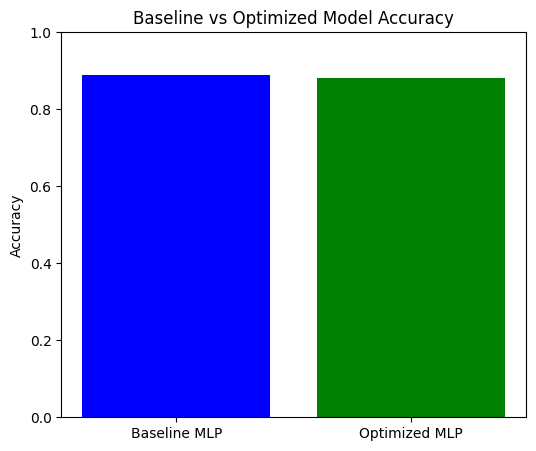

In [33]:
models = [
    "Baseline MLP",
    "Optimized MLP"
]

accuracy_values = [
    accuracy,
    optimized_accuracy
]

plt.figure(figsize=(6,5))
plt.bar(
    models,
    accuracy_values,
    color=['blue','green']
)


plt.title("Baseline vs Optimized Model Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.savefig("baseline_vs_optimized_accuracy.eps",
            format="eps",
            dpi=300,
            bbox_inches="tight")
plt.show()
